# CSCE 40103 Module 5 - Lab 4
## LAB 4: NETWORK ANOMALY DETECTION WITH FLOW RECORDS

**Dataset used:** RT_IOT2022.csv

Date - Jun 25 2026
Name - Bryant Baum


## LOAD THE DATASET



In [57]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV = Path("RT_IOT2022.csv")
RANDOM_STATE = 40103

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


In [58]:
def load_dataset(local_csv: Path = LOCAL_CSV) -> pd.DataFrame:
    # Load the PDF malware dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df


df = load_dataset()
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Loading local CSV file: RT_IOT2022.csv
Dataset loaded successfully.
Shape: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,761.985779,2.972918e+07,3.201160e+07,4.001450e+06,1.040307e+07,4438.877106,1.511694e+06,2.026391e+06,506597.757339,680406.147126,761.985779,2.972918e+07,3.201160e+07,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.282415e+06,2.282415e+06,2.282415e+06,2.282415e+06,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,247.001648,2.985528e+07,3.188358e+07,3.985448e+06,1.046346e+07,4214.048386,1.576436e+06,1.876261e+06,469065.248966,741351.686212,247.001648,2.985528e+07,3.188358e+07,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.028307e+06,2.028307e+06,2.028307e+06,2.028307e+06,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,283.956528,2.984215e+07,3.212405e+07,4.015507e+06,1.044238e+07,2456.903458,1.476049e+06,2.013770e+06,503442.466259,660344.360027,283.956528,2.984215e+07,3.212405e+07,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.281904e+06,2.281904e+06,2.281904e+06,2.281904e+06,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,288.963318,2.991377e+07,3.196106e+07,3.995133e+06,1.048253e+07,3933.906555,1.551892e+06,1.883784e+06,470946.013927,724569.317911,288.963318,2.991377e+07,3.196106e+07,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.047288e+06,2.047288e+06,2.047288e+06,2.047288e+06,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.

## INSPECT LABELS

Display the class counts and class percentages for Attack type.

Create a binary label for evaluation only:
normal traffic = 0 and attack traffic = 1

### Convert attack labels

In [59]:
attack_label = ["DOS_SYN_Hping","ARP_poisioning","NMAP_UDP_SCAN","NMAP_UDP_SCAN","NMAP_XMAS_TREE_SCAN","NMAP_OS_DETECTION","NMAP_TCP_scan","DDOS_Slowloris","Metasploit_Brute_Force_SSH","NMAP_FIN_SCAN"]
df["label"] = np.where(df["Attack_type"].isin(attack_label), 1, 0)

label counts:
label
1    110610
0     12507
Name: count, dtype: int64
label percentages:
label
1    89.84
0    10.16
Name: proportion, dtype: float64


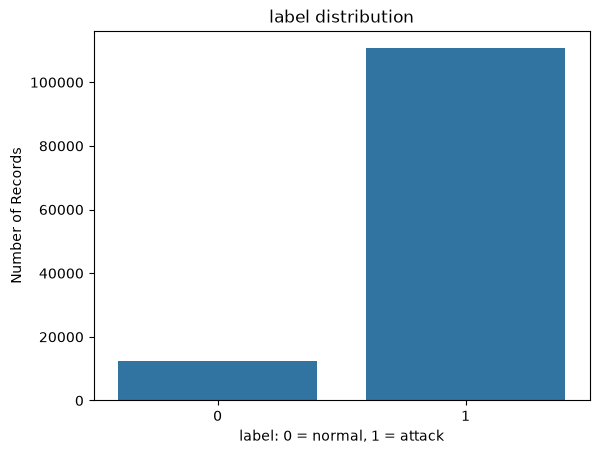

In [60]:
label_counts = df["label"].value_counts()
label_percentages = df["label"].value_counts(normalize=True) * 100
print("label counts:")
print(label_counts)
print("label percentages:")
print(label_percentages.round(2))
sns.countplot(data=df, x="label")
plt.title("label distribution")
plt.xlabel("label: 0 = normal, 1 = attack")
plt.ylabel("Number of Records")
plt.show()

# INSPECT COLUMNS AND DATA TYPES

In [61]:
print('Dataset source: RT_IOT2022.csv')
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))
print(df["Attack_type"].value_counts())

Dataset source: RT_IOT2022.csv
Shape: (123117, 86)

Columns:
['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow

,dtype
Unnamed: 0,int64
id.orig_p,int64
id.resp_p,int64
proto,str
service,str
flow_duration,float64
fwd_pkts_tot,int64
bwd_pkts_tot,int64
fwd_data_pkts_tot,int64
bwd_data_pkts_tot,int64


Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


### Drop columns

In [62]:
remove_columns = [
    "Unnamed: 0", "id.orig_p", "id.resp_p"
]
df.drop(columns=remove_columns, inplace=True)



### Select numeric columns

In [ ]:
df_numeric = df.select_dtypes(include='number')
display(df_numeric.dtypes.to_frame('dtype'))
print("Number of selected features: ", len(df_numeric.columns))

,dtype
flow_duration,float64
fwd_pkts_tot,int64
bwd_pkts_tot,int64
fwd_data_pkts_tot,int64
bwd_data_pkts_tot,int64
fwd_pkts_per_sec,float64
bwd_pkts_per_sec,float64
flow_pkts_per_sec,float64
down_up_ratio,float64
fwd_header_size_tot,int64


Number of columns:  80


# CREATE BENIGN TRAINING DATA AND MIXED EVALUATION DATA
Create a training set using only benign records.
Create an evaluation set containing both benign and attack records.
Do not train unsupervised anomaly detectors on the label.
Use the label only after scoring to evaluate and interpret results.
For RT-IoT2022, treat normal traffic categories as benign and all attack categories as attack
when creating the evaluation labels.

In [ ]:
df_benign = df_numeric[df_numeric["label"] == 0]


(12507, 80)

# CLEAN MISSING AND INFINITE VALUES
Check whether the dataset contains missing values and duplicate rows.

In [31]:
df.replace([np.inf,-np.inf], np.nan)
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print('Duplicate rows:', duplicate_count)
print('\nMissing values:')
display(missing_summary[missing_summary > 0].to_frame('missing_count'))

if missing_summary.sum() == 0:
    print('No missing values found.')

Duplicate rows: 0

Missing values:


,missing_count


No missing values found.


# SELECT NUMERIC FLOW FEATURES

Create a list of numeric feature columns.

Remove the label column.

Remove obvious identifier columns if they exist, such as IP address, Flow ID,

timestamp, or raw identifier fields.

Keep only numeric behavior features.

Examples of useful feature types include duration, packets, bytes, flow rate, packet
length statistics, inter-arrival time statistics, and TCP flag counts.

# 4. Scale Features and Apply PCA

Explained variance ratio: [0.17050285 0.10981628]


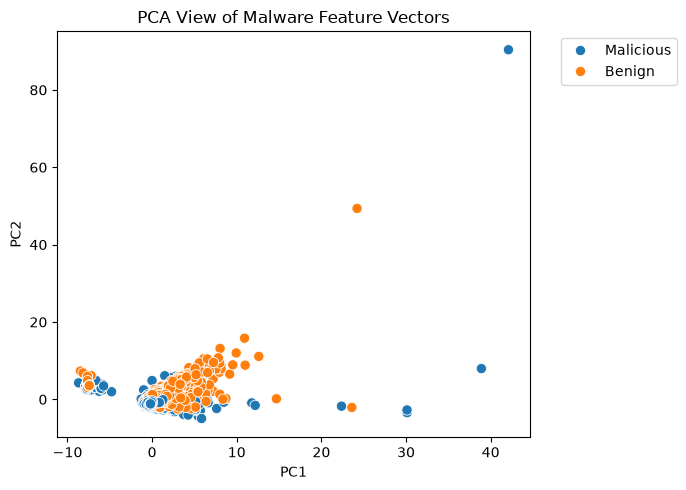

In [252]:
df_scaled = StandardScaler().fit_transform(feature_df)
pca = PCA(n_components=2, random_state=40103)
X_pca = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

label_col = "Class"
if label_col:
    pca_df[label_col] = df[label_col].astype(str).values

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
if label_col:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_col, s=55)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=55)
plt.title("PCA View of Malware Feature Vectors")
plt.tight_layout()
plt.show()

# Explanation

- It is important to scale features when training with K-means, hierarchical clustering, DBSCAN, or silhouette score, because these algorithms require calculating features by 'distance' and scaling makes sure that each feature is contributing a balanced proportion of magnitude rather than features with large values dominating the space. 

## 5. K-Means Clustering

In [253]:
def evaluate_k_range(X_scaled, k_values, random_state=40103):
    rows = []
    for k in k_values:
        model = KMeans(
            n_clusters=k,
            max_iter=300,
            n_init=20,
            random_state=random_state
        )
        labels = model.fit_predict(X_scaled)
        inertia = model.inertia_
        sil = np.nan
        if k >= 2:
            sil = silhouette_score(X_scaled, labels)
        rows.append({'K': k, 'inertia': inertia, 'silhouette': sil})
    return pd.DataFrame(rows)

k_values = range(2, 9)
k_eval = evaluate_k_range(df_scaled, k_values, RANDOM_STATE)
display(k_eval.round(3))

,K,inertia,silhouette
0,2,269500.793,0.538
1,3,249741.990,0.438
2,4,229345.986,0.431
3,5,215182.821,0.409
4,6,202006.629,0.398
5,7,187223.088,0.278
6,8,174236.976,0.265


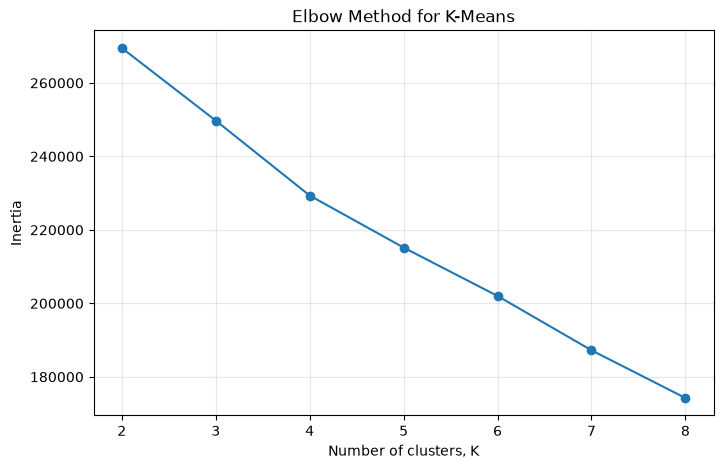

In [254]:
plt.figure(figsize=(8, 5))
plt.plot(k_eval['K'], k_eval['inertia'], marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.xticks(k_eval['K'])
plt.grid(True, alpha=0.3)
plt.show()

Chosen K: 2
Cluster counts:
0     554
1    9469
Name: count, dtype: int64

Inertia: 269500.793
Silhouette score: 0.538

Known Class vs K-Means cluster:


Cluster,0,1
Class,,
Benign,33,4435
Malicious,521,5034


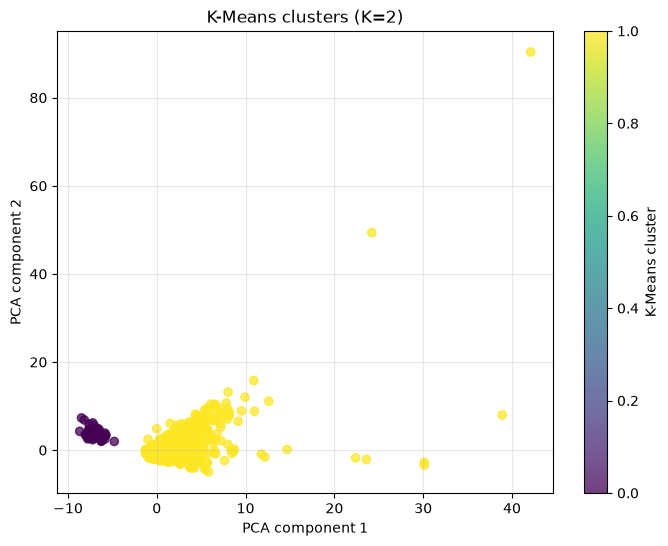

Explained variance ratio: [0.171 0.11 ]


In [ ]:
def plot_clusters_pca(X_scaled, cluster_labels, title):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, alpha=0.75)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.colorbar(scatter, label="K-Means cluster")
    plt.show()

    print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

# auto picks the k with the best silhouette value
CHOSEN_K = int(k_eval.sort_values("silhouette", ascending=False).iloc[0]["K"])
print("Chosen K:", CHOSEN_K)

final_kmeans = KMeans(
    n_clusters=CHOSEN_K,
    max_iter=300,
    n_init=20,
    random_state=RANDOM_STATE
)
cluster_labels = final_kmeans.fit_predict(df_scaled)
df["kmeans_cluster"] = cluster_labels

print("Cluster counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print("\nInertia:", round(final_kmeans.inertia_, 3))
print("Silhouette score:", round(silhouette_score(df_scaled, cluster_labels), 3))

if label_col:
    print("\nKnown Class vs K-Means cluster:")
    display(pd.crosstab(df[label_col], df["kmeans_cluster"], rownames=["Class"], colnames=["Cluster"]))

plot_clusters_pca(df_scaled, cluster_labels, f"K-Means clusters (K={CHOSEN_K})")

# Explanation
- The evaluate_k_range function was run in order to see how many clusters are optimal. 2 centroids/clusters appears to be the optimal k based on the silhouette score, so that is what was used in K_Means clustering algorithm and that is what is displayed on the above PCA graph. 

## 6. Hierarchical Clustering and Linkage Methods

# DENDOGRAM

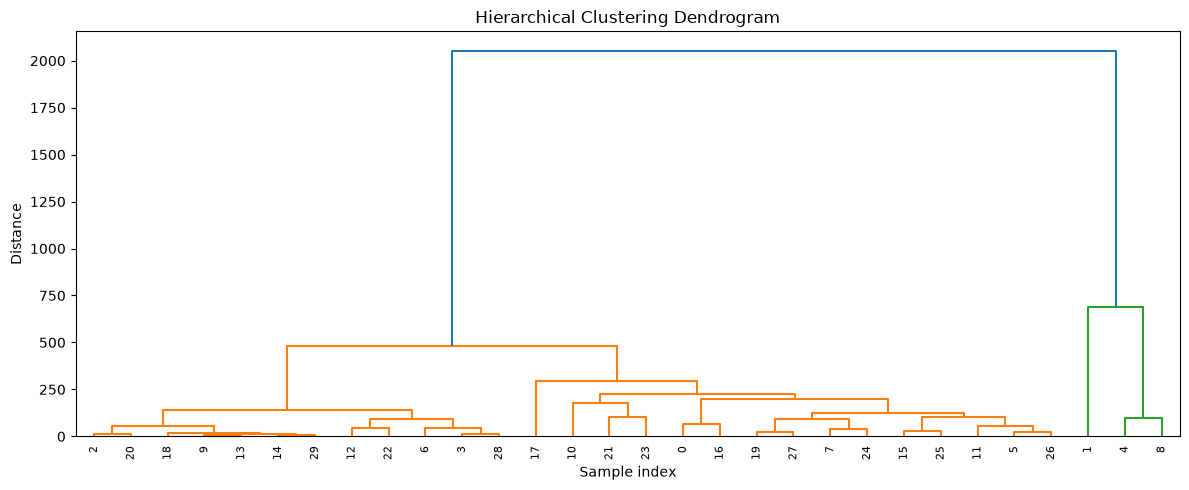

In [256]:
max_points_for_dendrogram = 30
sample_df = feature_df.copy()

if len(sample_df) > max_points_for_dendrogram:
    sample_df = sample_df.sample(max_points_for_dendrogram, random_state=RANDOM_STATE)

Z = linkage(sample_df, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# AGGLOMERATIVE CLUSTERING

,k,silhouette_score
0,2,0.523920
1,3,0.525336
2,4,0.219282
3,5,0.219130
4,6,0.219053
5,7,0.222546
6,8,0.234832


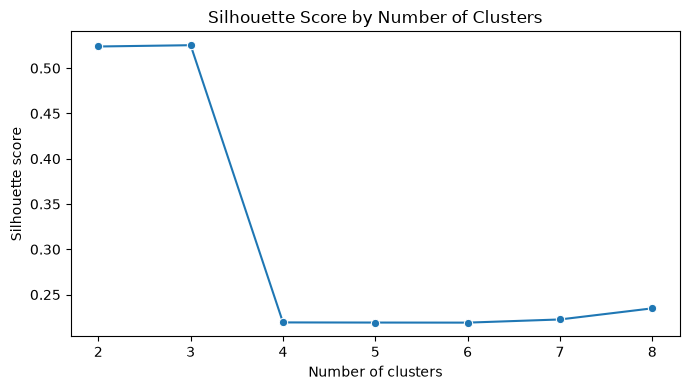

In [257]:
results = []
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    results.append({"k": k, "silhouette_score": score})

results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(7, 4))
sns.lineplot(data=results_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

In [258]:
best_k = int(results_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
# best_k = 4
print("Selected K:", best_k)

final_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
cluster_labels = final_model.fit_predict(df_scaled)

df_hier = df.copy()
df_hier["hier_cluster"] = cluster_labels

print(df_hier["hier_cluster"].value_counts().sort_index())

Selected K: 3
hier_cluster
0    9481
1     541
2       1
Name: count, dtype: int64


# Explanation
- k - 3 has the best silhouette so will start with that one. ~~Ended up changing it to 2, because 3 didn't look much better.~~ Changed it back to 3 after generating the linkage table 

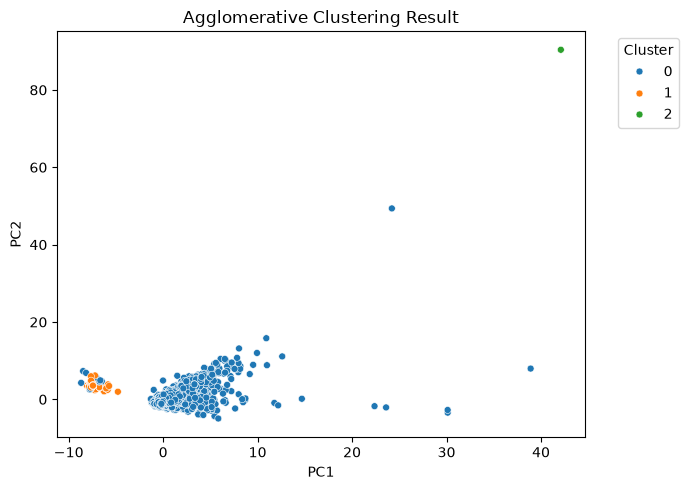

In [259]:
plot_df = pca_df.copy()
plot_df["hier_cluster"] = cluster_labels.astype(str)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="hier_cluster", s=25)
plt.title("Agglomerative Clustering Result")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

,linkage,k,silhouette_score
14,average,2,0.961185
7,complete,2,0.961185
21,single,2,0.961185
15,average,3,0.953223
8,complete,3,0.953223
22,single,3,0.952698
16,average,4,0.952683
9,complete,4,0.952683
23,single,4,0.952683
17,average,5,0.925907


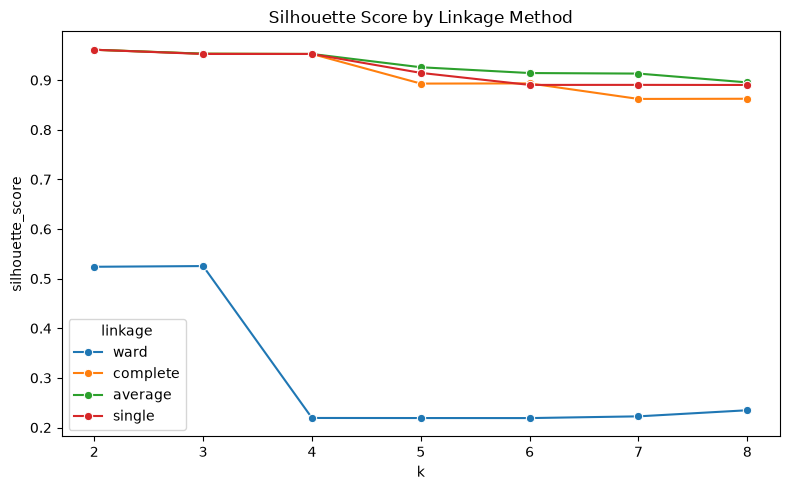

In [260]:
linkage_results = []

for linkage_name in ["ward", "complete", "average", "single"]:
    for k in range(2, 9):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage_name)
        labels = model.fit_predict(df_scaled)
        score = silhouette_score(df_scaled, labels)
        linkage_results.append({
            "linkage": linkage_name,
            "k": k,
            "silhouette_score": score
        })

linkage_df = pd.DataFrame(linkage_results)
display(linkage_df.sort_values("silhouette_score", ascending=False).head(10))

plt.figure(figsize=(8, 5))
sns.lineplot(data=linkage_df, x="k", y="silhouette_score", hue="linkage", marker="o")
plt.title("Silhouette Score by Linkage Method")
plt.tight_layout()
plt.show()

# Interpretation
- The linkage table makes 2 through 4 look like reasonable k-values. The ward linkage silhouette score is lower than the others because it is trying to divide up the large dense cluster created by overlapping features. 

# 7. DBSCAN Clustering 

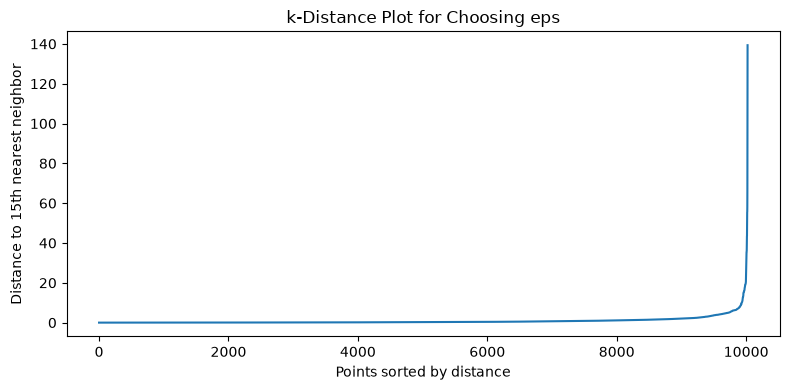

Suggested starting eps values to try:
[0.648 0.849 1.141 1.459 2.033 3.77 ]


In [ ]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title("k-Distance Plot for Choosing eps")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.tight_layout()
plt.show()

print("Suggested starting eps values to try:")
print(np.round(np.percentile(k_distances, [70, 75, 80, 85, 90, 95]), 3))

In [273]:
eps = float(np.percentile(k_distances, 85))
print("Starting eps:", round(eps, 3))
print("min_samples:", min_samples)

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(df_scaled)

df_db = df.copy()
df_db["dbscan_cluster"] = db_labels

display(df_db["dbscan_cluster"].value_counts().sort_index())

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int((db_labels == -1).sum())

print("Clusters found:", n_clusters)
print("Noise points:", n_noise)

Starting eps: 1.459
min_samples: 15


dbscan_cluster
-1     1141
 0     1666
 1      194
 2      498
 3     2742
 4      176
 5       71
 6       75
 7       15
 8     2022
 9       81
 10      44
 11      83
 12      39
 13      23
 14      16
 15      32
 16      15
 17      56
 18      31
 19     300
 20     155
 21      22
 22      15
 23      25
 24      24
 25     116
 26      19
 27      15
 28      16
 29      15
 30     265
 31      16
Name: count, dtype: int64

Clusters found: 32
Noise points: 1141


# Compute Silhouette Score

In [274]:
non_noise_mask = db_labels != -1
non_noise_labels = db_labels[non_noise_mask]

if len(set(non_noise_labels)) >= 2:
    score = silhouette_score(df_scaled[non_noise_mask], non_noise_labels)
    print("Silhouette score on non-noise points:", round(score, 4))
else:
    print("Silhouette score not computed: fewer than two non-noise clusters.")

Silhouette score on non-noise points: 0.3721


# Visualize DBSCAN Clusters

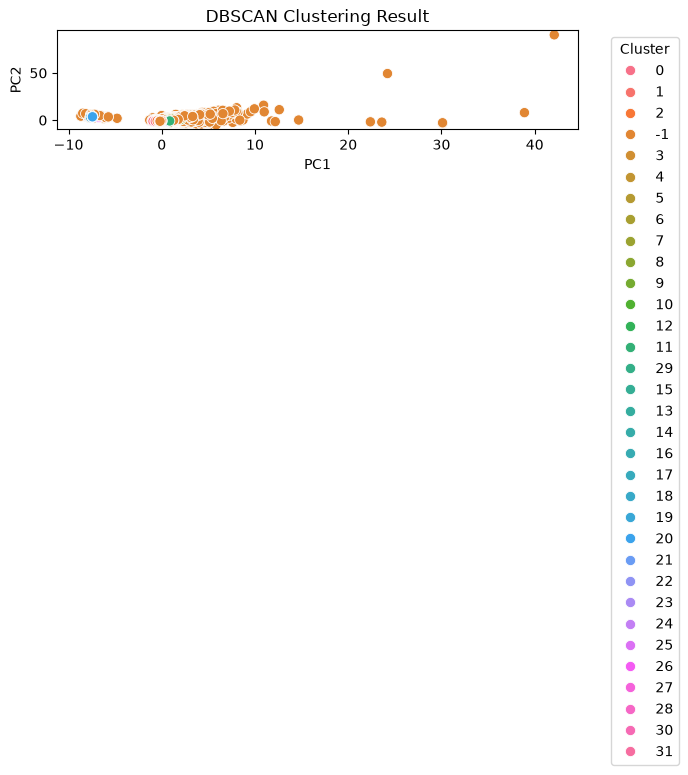

In [275]:
plot_df = pca_df.copy()
plot_df["dbscan_cluster"] = db_labels.astype(str)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="dbscan_cluster", s=55)
plt.title("DBSCAN Clustering Result")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Tune eps and min_samples

In [265]:
eps_values = np.round(np.percentile(k_distances, [70, 75, 80, 85, 90, 95]), 3)
min_samples_values = [4, 5, 8, 10]

sweep_rows = []

for ms in min_samples_values:
    for ep in eps_values:
        model = DBSCAN(eps=float(ep), min_samples=ms)
        labels = model.fit_predict(df_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        noise_rate = n_noise / len(labels)

        mask = labels != -1
        if len(set(labels[mask])) >= 2:
            sil = silhouette_score(df_scaled[mask], labels[mask])
        else:
            sil = np.nan

        sweep_rows.append({
            "eps": ep,
            "min_samples": ms,
            "clusters": n_clusters,
            "noise_rate": round(noise_rate, 3),
            "silhouette_non_noise": sil
        })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.sort_values(["silhouette_non_noise", "clusters"], ascending=[False, False]).head(15))

,eps,min_samples,clusters,noise_rate,silhouette_non_noise
19,0.324,10,76,0.347,0.609725
13,0.324,8,95,0.324,0.597338
18,0.240,10,88,0.400,0.582433
20,0.466,10,76,0.283,0.576709
12,0.240,8,100,0.381,0.567025
21,0.671,10,78,0.223,0.558380
14,0.466,8,92,0.263,0.553035
15,0.671,8,89,0.209,0.550538
9,0.671,5,134,0.170,0.524925
7,0.324,5,150,0.279,0.523040


# Select practical DBSCAN Setting

In [266]:
candidates = sweep_df[
    (sweep_df["clusters"] >= 2) &
    (sweep_df["noise_rate"] < 0.40)
].dropna(subset=["silhouette_non_noise"])

if len(candidates) > 0:
    chosen = candidates.sort_values("silhouette_non_noise", ascending=False).iloc[0]
else:
    chosen = sweep_df.sort_values("clusters", ascending=False).iloc[0]

best_eps = float(chosen["eps"])
best_min_samples = int(chosen["min_samples"])

print("Chosen eps:", best_eps)
print("Chosen min_samples:", best_min_samples)

final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_labels = final_dbscan.fit_predict(df_scaled)

df_db["dbscan_cluster_final"] = final_labels
display(df_db["dbscan_cluster_final"].value_counts().sort_index())

Chosen eps: 0.324
Chosen min_samples: 10


dbscan_cluster_final
-1     3481
 0     1212
 1      184
 2      255
 3      199
 4       79
 5      701
 6      157
 7       40
 8       35
 9       15
 10     190
 11      12
 12      42
 13      39
 14      19
 15      15
 16      17
 17      11
 18      21
 19      23
 20      15
 21      13
 22     149
 23      23
 24      15
 25      13
 26      27
 27      23
 28     268
 29      21
 30      15
 31      72
 32      20
 33      27
 34      17
 35      14
 36      12
 37      17
 38      20
 39      13
 40      23
 41      14
 42      11
 43      13
 44     352
 45      18
 46      15
 47      33
 48     276
 49      15
 50      94
 51      25
 52      31
 53      12
 54     381
 55      15
 56     134
 57      16
 58     136
 59      15
 60      14
 61      14
 62      40
 63      62
 64      24
 65      11
 66     437
 67      24
 68      20
 69      13
 70      10
 71      11
 72      37
 73      92
 74      15
 75      29
Name: count, dtype: int64

# Inspect Noise

,PdfSize,MetadataSize,Pages,XrefLength,TitleCharacters,isEncrypted,EmbeddedFiles,Images,Text,Header,Obj,Endobj,Stream,Endstream,Xref,Trailer,StartXref,PageNo,Encrypt,ObjStm,JS,Javascript,AA,OpenAction,Acroform,JBIG2Decode,RichMedia,Launch,EmbeddedFile,XFA,Colors
dbscan_cluster_final,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
-1,163.93,477.81,6.87,4650.44,135.04,-0.04,-0.01,4.45,0.64,1.52,106.54,112.09,37.29,39.19,1.45,1.51,1.97,6.46,0.01,3.69,0.94,1.15,0.84,0.17,0.62,0.09,-0.01,-0.01,0.78,0.03,3.91
0,36.34,232.25,1.01,42.27,3.80,0.00,0.00,-0.11,0.00,1.33,10.59,10.59,2.89,2.89,1.00,1.00,1.00,1.62,0.00,0.00,1.04,1.29,0.02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02
1,27.81,231.58,0.97,40.91,3.07,0.00,0.00,-0.12,0.00,1.60,19.18,19.18,9.09,9.09,1.00,1.00,1.00,1.09,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,8.00,1.00,0.00
2,45.95,323.70,3.25,27.46,21.67,0.00,0.00,0.60,1.00,1.31,9.08,9.08,2.56,2.56,1.00,1.00,1.00,1.09,0.00,0.00,0.98,1.10,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02
3,37.36,225.40,0.95,37.21,3.56,0.00,0.00,-0.06,0.00,1.35,14.18,14.18,2.06,2.06,1.00,1.00,1.00,1.05,0.00,0.00,2.00,3.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,19.37,218.95,0.91,20.72,1.61,0.00,0.00,0.01,0.00,1.41,16.75,16.72,2.77,2.77,1.00,1.00,1.00,1.00,0.00,0.00,1.34,2.32,0.03,0.00,1.00,0.00,0.00,0.00,0.00,0.00,-0.01
5,46.83,250.06,1.02,25.36,1.41,0.00,0.00,3.18,0.00,1.30,9.53,9.58,2.76,2.71,1.00,1.00,1.00,1.02,0.00,0.00,0.50,0.73,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.18
6,31.78,218.24,0.91,34.25,1.85,0.00,0.00,-0.04,0.00,7.30,8.22,7.76,2.15,2.15,1.00,1.00,1.00,1.00,0.00,0.00,0.27,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,27.15,211.08,0.90,62.38,2.28,0.00,0.00,0.10,0.00,1.40,28.38,28.00,3.62,3.62,1.00,1.00,1.00,1.00,0.00,0.00,1.00,2.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00


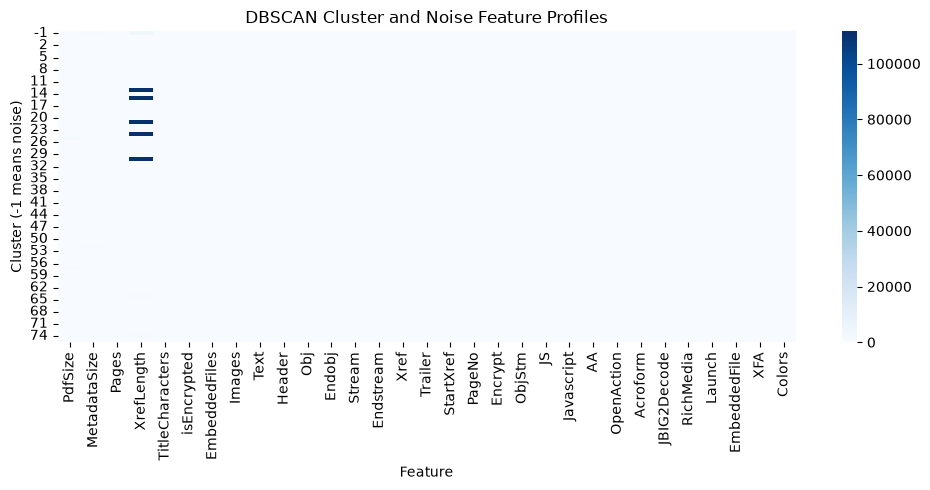

In [276]:
profile_df = feature_df.copy()
profile_df["dbscan_cluster_final"] = final_labels

profile = profile_df.groupby("dbscan_cluster_final").mean().round(2)
display(profile)

plt.figure(figsize=(10, 5))
sns.heatmap(profile, cmap="Blues", annot=False)
plt.title("DBSCAN Cluster and Noise Feature Profiles")
plt.xlabel("Feature")
plt.ylabel("Cluster (-1 means noise)")
plt.tight_layout()
plt.show()

# Explanation

- The dbscan did not seem to work well for this dataset. There are too many features and the features have too similar of flags. 

In [280]:
def cluster_summary(name, params, labels, notes, has_noise=False):
    labels = np.asarray(labels)
    noise = int((labels == -1).sum())
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    if n_clusters >= 2:
        sil = round(silhouette_score(df_scaled[mask], labels[mask]), 3)
    else:
        sil = np.nan
    return {
        "method": name,
        "Parameters Used": params,
        "number of clusters": n_clusters,
        "noise_points": noise if has_noise else "N/A",
        "silhouette": sil,
        "Interpretation": notes,
    }

summary_rows = [
    cluster_summary(
        "K-Means", "k=2", df["kmeans_cluster"].values,
        f"K={CHOSEN_K} chosen by silhouette"),
    cluster_summary(
        "Hierarchical (Ward)", "k=3",df_hier["hier_cluster"].values,
        f"K={best_k} one dominating dense cluster"),
    cluster_summary(
        "DBSCAN","eps=0.3, min_samples=10", final_labels,
        f"eps={best_eps}, min_samples={best_min_samples}. Lot of micro clusters and noise",
        has_noise=True),
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,method,Parameters Used,number of clusters,noise_points,silhouette,Interpretation
0,K-Means,k=2,2,N/A,0.538,K=2 chosen by silhouette
1,Hierarchical (Ward),k=3,3,N/A,0.525,K=3 one dominating dense cluster
2,DBSCAN,"eps=0.3, min_samples=10",76,3481,0.610,"eps=0.324, min_samples=10. Lot of micro cluste..."


# Interpretation

K-means clustering provided the best results for this dataset. Using a k-value of 2 the results were the clearest. The hierarchical clustering had a low silhouette score and made a very dense cluster. DBSCAN was unable to meaningfully separate all of the data, because it had such high dimensionality. 